## 🔍 Part 4: Exploratory Data Analysis 

We study our dataset to understand its overall shape, individual columns, connections, and hidden trends. We load our data directly from our database.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Connect to our database and load the unified data
conn = sqlite3.connect("../student_records.db")
query = """
SELECT 
    c.student_id, c.age, c.sex, c.address,
    b.Medu, b.Fedu, b.schoolsup, b.famsup,
    l.studytime, l.goout, l.Dalc, l.Walc, l.health,
    p.failures, p.absences, p.G1, p.G2, p.G3
FROM STUDENT_CORE c
JOIN STUDENT_BACKGROUND b ON c.student_id = b.student_id
JOIN STUDENT_LIFESTYLE l  ON c.student_id = l.student_id
JOIN STUDENT_PERFORMANCE p ON c.student_id = p.student_id;
"""
df = pd.read_sql_query(query, conn)
conn.close()

print("✅ Data successfully loaded for analysis!")

✅ Data successfully loaded for analysis!


### 🗃️ Descriptive Statistics
We will look at the basic summaries of our numerical columns, count our categorical words, and check if any data is missing.

In [3]:
print("--- 1. NUMERICAL COLUMNS SUMMARY ---")
display(df.describe())

print("\n--- 2. CATEGORICAL COLUMNS VALUE COUNTS ---")
categorical_cols = ['sex', 'address', 'schoolsup', 'famsup']
for col in categorical_cols:
    print(f"\nValue Counts for '{col}':")
    print(df[col].value_counts())

print("\n--- 3. MISSING VALUES CHECK ---")
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_pct})
display(missing_df)

--- 1. NUMERICAL COLUMNS SUMMARY ---


,student_id,age,Medu,Fedu,studytime,goout,Dalc,Walc,health,failures,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,198.000000,16.696203,2.749367,2.521519,2.035443,3.108861,1.481013,2.291139,3.554430,0.334177,5.708861,10.908861,10.713924,10.415190
std,114.170924,1.276043,1.094735,1.088201,0.839240,1.113278,0.890741,1.287897,1.390303,0.743651,8.003096,3.319195,3.761505,4.581443
min,1.000000,15.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,99.500000,16.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,8.000000,9.000000,8.000000
50%,198.000000,17.000000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,4.000000,0.000000,4.000000,11.000000,11.000000,11.000000
75%,296.500000,18.000000,4.000000,3.000000,2.000000,4.000000,2.000000,3.000000,5.000000,0.000000,8.000000,13.000000,13.000000,14.000000
max,395.000000,22.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,3.000000,75.000000,19.000000,19.000000,20.000000



--- 2. CATEGORICAL COLUMNS VALUE COUNTS ---

Value Counts for 'sex':
sex
F    208
M    187
Name: count, dtype: int64

Value Counts for 'address':
address
U    307
R     88
Name: count, dtype: int64

Value Counts for 'schoolsup':
schoolsup
no     344
yes     51
Name: count, dtype: int64

Value Counts for 'famsup':
famsup
yes    242
no     153
Name: count, dtype: int64

--- 3. MISSING VALUES CHECK ---


,Missing Count,Percentage (%)
student_id,0,0.0
age,0,0.0
sex,0,0.0
address,0,0.0
Medu,0,0.0
Fedu,0,0.0
schoolsup,0,0.0
famsup,0,0.0
studytime,0,0.0
goout,0,0.0


#### 📝 Summary Interpretation
Our dataset contains 395 students. The average age of a student is around 16.7 years old, with the youngest being 15 and the oldest being 22. When looking at final grades (G3), the average score is 10.4 out of 20, but some students scored a flat 0. Most students live in urban areas (U) rather than rural ones (R). Finally, our data is completely clean because there are zero missing values in any column.

### 📈 1. Univariate Analysis

We look at each column completely on its own using histograms, boxplots, and bar charts to find weird patterns and data shapes.

C:\Users\User\AppData\Local\Temp\ipykernel_5012\3940159653.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_5012\3940159653.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='address', data=df, palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_5012\3940159653.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='schoolsup', data=df, palette='Set2')


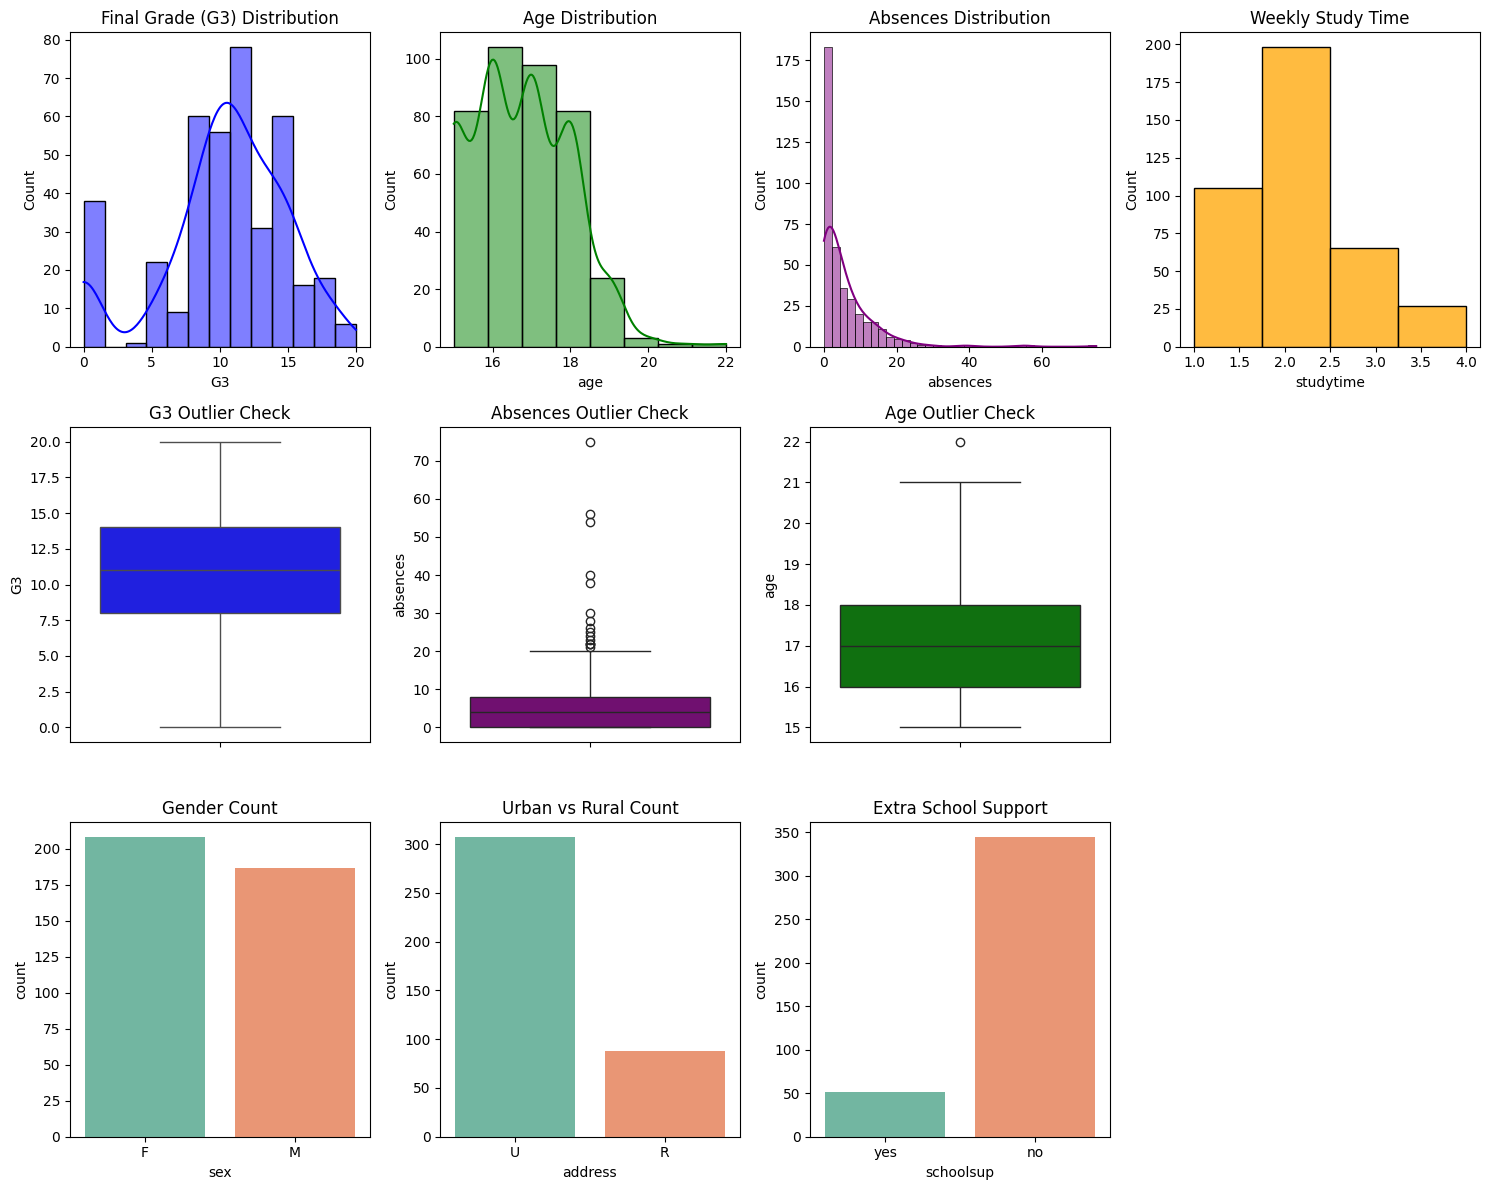

In [4]:
# Create a big layout for our charts
plt.figure(figsize=(15, 12))

# 1. Histograms for Numerical Columns (4 charts)
plt.subplot(3, 4, 1)
sns.histplot(df['G3'], kde=True, color='blue')
plt.title('Final Grade (G3) Distribution')

plt.subplot(3, 4, 2)
sns.histplot(df['age'], kde=True, color='green', bins=8)
plt.title('Age Distribution')

plt.subplot(3, 4, 3)
sns.histplot(df['absences'], kde=True, color='purple')
plt.title('Absences Distribution')

plt.subplot(3, 4, 4)
sns.histplot(df['studytime'], color='orange', bins=4)
plt.title('Weekly Study Time')

# 2. Boxplots to identify Outliers (3 charts)
plt.subplot(3, 4, 5)
sns.boxplot(y=df['G3'], color='blue')
plt.title('G3 Outlier Check')

plt.subplot(3, 4, 6)
sns.boxplot(y=df['absences'], color='purple')
plt.title('Absences Outlier Check')

plt.subplot(3, 4, 7)
sns.boxplot(y=df['age'], color='green')
plt.title('Age Outlier Check')

# 3. Bar Charts for Categorical Columns (3 charts)
plt.subplot(3, 4, 9)
sns.countplot(x='sex', data=df, palette='Set2')
plt.title('Gender Count')

plt.subplot(3, 4, 10)
sns.countplot(x='address', data=df, palette='Set2')
plt.title('Urban vs Rural Count')

plt.subplot(3, 4, 11)
sns.countplot(x='schoolsup', data=df, palette='Set2')
plt.title('Extra School Support')

plt.tight_layout()
plt.show()

#### 📝 Chart Observations

* **Final Grade (G3) Histogram & Boxplot:** Most students form a bell-shaped curve between scores of 8 and 15. But a group of 38 students sitting at a flat 0. The boxplot shows the middle line (median) sits right at 11.

* **Absences (The Outlier):** Most students miss very few days of school (between 0 and 4 days). However, the boxplot reveals massive outliers on the right side. A few extreme students missed 30, 40, or even over 70 days of school!

* **Age Outlier:** The age boxplot confirms that almost all students fit neatly between 15 and 18. The age of 22 shows up as a single dot at the very top because it is highly unusual for this school group.

* **Categorical Groups:** Our gender count is almost perfectly split down the middle between males and females. Also, very few students (around 50) get extra tutoring support from the school, while the  majority (nearly 340) do not.

### 📊 What This Chart Tells Us: The Dropout Problem

* Most students score around a 10 or 11. But there is a huge spike of 38 students who got a flat 0.

* **What it means:** These 38 students dropped out before the final exam.

* **How it helps our AI:** If we try to predict grades with one simple math rule, these 38 zeros will break our calculations. Our AI needs to work in two steps:
    1. Guess if a student is going to drop out (Yes or No).
    2. If they stay in school, guess their exact final score (from 1 to 20).

### 🕵️‍♂️ 2. Bivariate and Multivariate Analysis

Now we see how different columns connect to each other and look for our top predictors.

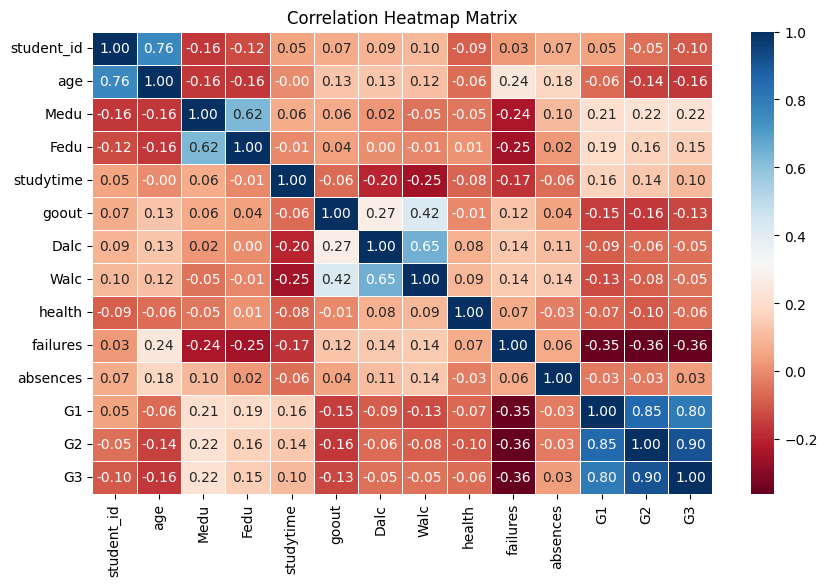

Top 3 Strongest Day-1 Predictors (Ignoring G1/G2):
failures    0.360415
Medu        0.217147
age         0.161579
Name: G3, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_5012\2021325024.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, ax=axes[0, 1], palette='Blues')
C:\Users\User\AppData\Local\Temp\ipykernel_5012\2021325024.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='schoolsup', y='G3', data=df, ax=axes[1, 1], palette='Oranges')
C:\Users\User\AppData\Local\Temp\ipykernel_5012\2021325024.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='address', y='G3', data=df, ax=axes[2, 1], palette='Purples')


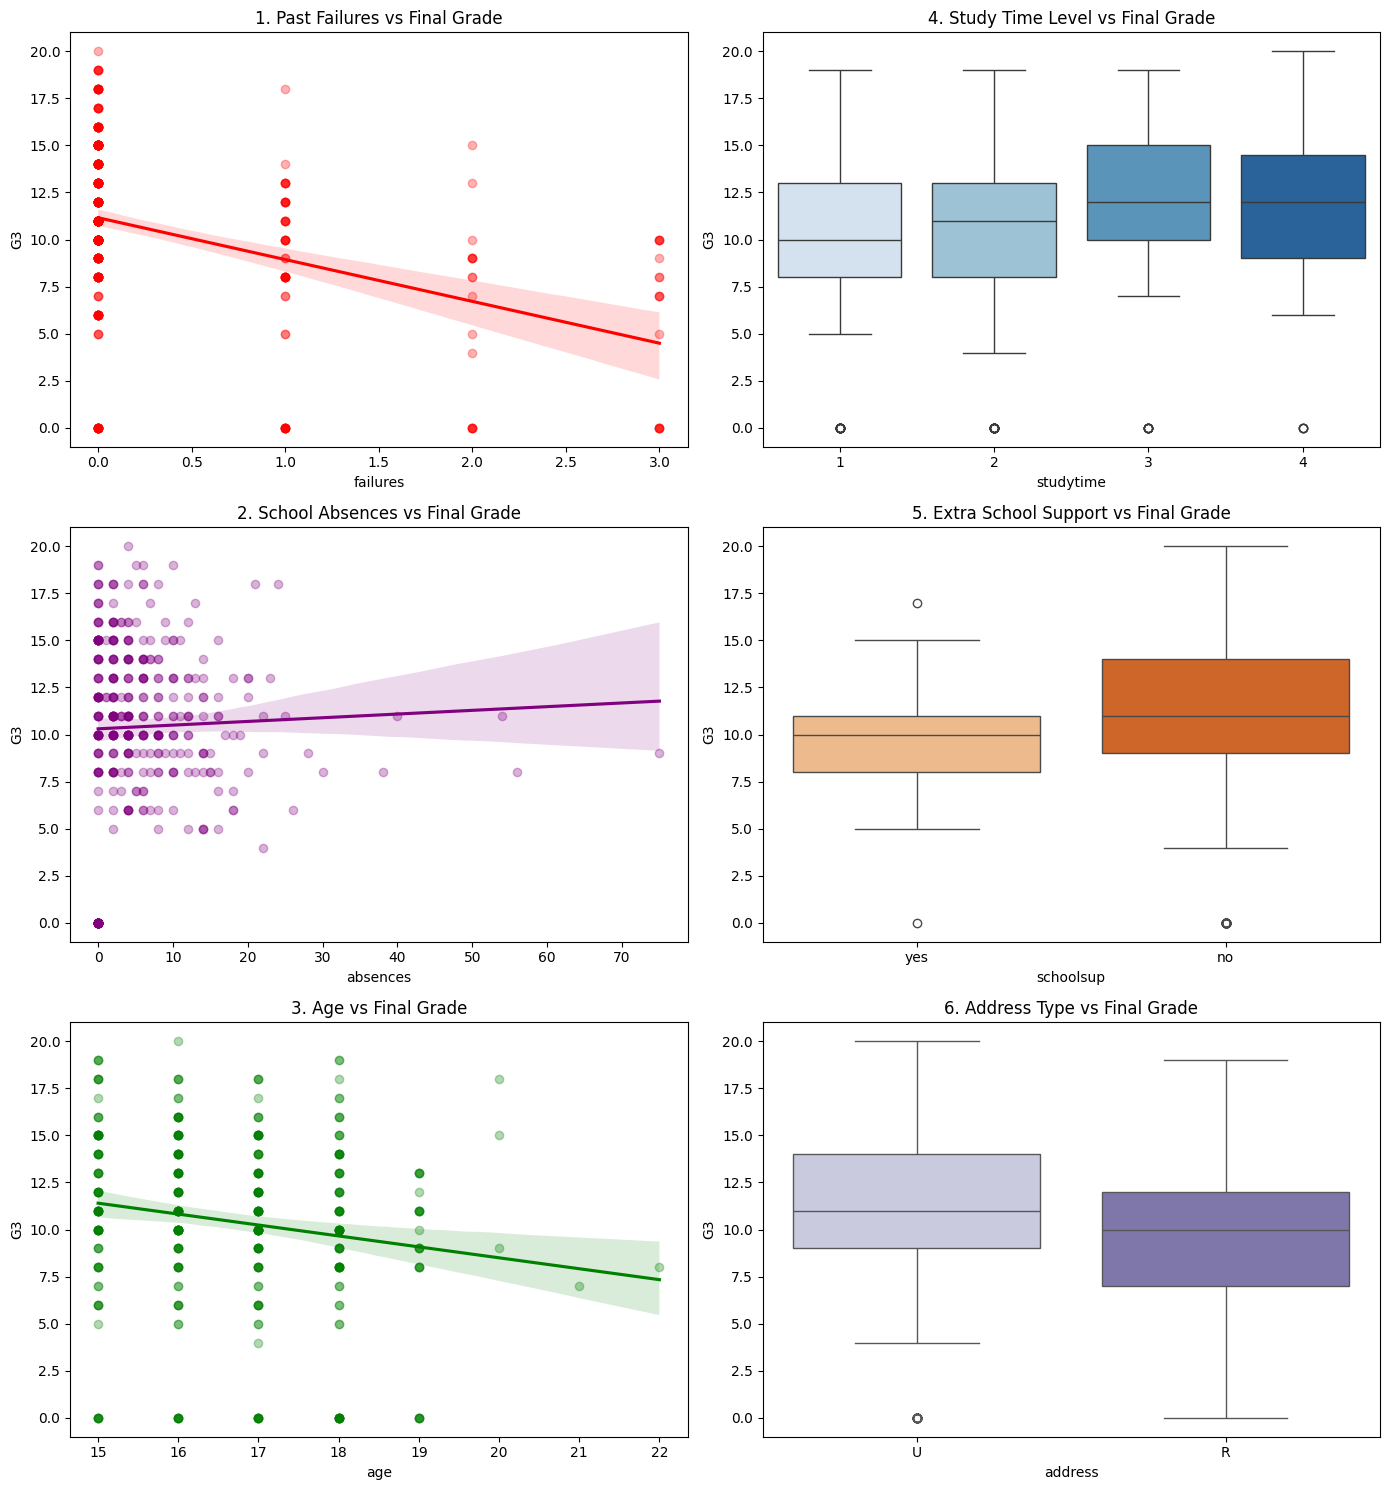

In [5]:
# 1. Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap Matrix')
plt.show()

# 2. Identify top Day-1 predictors (excluding G1 and G2 to avoid cheating/leakage)
# We calculate absolute correlation with G3
top_corrs = df[numeric_cols].corr()['G3'].abs().sort_values(ascending=False)
print("Top 3 Strongest Day-1 Predictors (Ignoring G1/G2):")
print(top_corrs.drop(['G3', 'G1', 'G2']).head(3))

# 3. A 6-chart combined subplot dashboard (3x2 grid)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Scatter / Trend Plots (Top 3 continuous features vs Target G3)
sns.regplot(x='failures', y='G3', data=df, ax=axes[0, 0], color='red', scatter_kws={'alpha':0.3})
axes[0, 0].set_title('1. Past Failures vs Final Grade')

sns.regplot(x='absences', y='G3', data=df, ax=axes[1, 0], color='purple', scatter_kws={'alpha':0.3})
axes[1, 0].set_title('2. School Absences vs Final Grade')

sns.regplot(x='age', y='G3', data=df, ax=axes[2, 0], color='green', scatter_kws={'alpha':0.3})
axes[2, 0].set_title('3. Age vs Final Grade')

# Box Plots (Categorical columns vs Target G3)
sns.boxplot(x='studytime', y='G3', data=df, ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('4. Study Time Level vs Final Grade')

sns.boxplot(x='schoolsup', y='G3', data=df, ax=axes[1, 1], palette='Oranges')
axes[1, 1].set_title('5. Extra School Support vs Final Grade')

sns.boxplot(x='address', y='G3', data=df, ax=axes[2, 1], palette='Purples')
axes[2, 1].set_title('6. Address Type vs Final Grade')

plt.tight_layout()
plt.show()

#### 📝 Relationship Findings

* **The Top 3 Day-1 Predictors:** Our system calculated that the three strongest day-1 clues for final grades are:
**Past class failures** (0.36 connection strength)
**Mother's education level (Medu)** (0.22 connection strength)
**Age** (0.16 connection strength).

* **Chart 1 (Past Failures vs. Grades):** The red trend line slopes downward sharply. This proves that if a student has failed classes in the past, their final grades drop drastically.

* **Chart 2 (Absences vs. Grades):** Surprisingly, the purple line is relatively flat. This means missing a few days of school doesn't automatically ruin your grade, though the students with extreme absences (over 40 days) struggle to get top scores.

* **Chart 3 (Age vs. Grades):** The green line slopes downward. This shows that older students in these classes tend to get slightly lower marks on average.

* **Chart 4 (Study Time vs. Grades):** The blue boxes move upward as study hours increase. Students who study 3 to 4 hours a week get noticeably better and more stable grades than those who study less than 1 hour.

* **Chart 5 (The School Support Surprise):** Look closely at the orange boxes! Students who receive extra school support actually have a *lower* average grade than those who don't. This makes sense in real life: the school only gives extra tutoring to students who are already falling behind.

* **Chart 6 (City vs. Countryside):** City students (U) have a slightly higher grade box than countryside students (R), showing that school location plays a small role in academic success.

In [6]:
print("=== RUNNING HYPOTHESIS TESTS ===")
print("--------------------------------")

# HYPOTHESIS 1: Study Time vs. Grades
print("\nHYPOTHESIS 1:")
print("Theory: 'Students with higher study time will score better in G3'")
study_time_means = df.groupby("studytime")["G3"].mean()
print("\nResult (Average Grade by Study Time Level):")
for level, mean_grade in study_time_means.items():
    print(f"Study Time Level {level}: {mean_grade:.1f} out of 20")
print("\nConclusion: CONFIRMED - Students who study more get higher average marks.")
print("--------------------------------")

# HYPOTHESIS 2: Past Failures vs. Grades
print("\nHYPOTHESIS 2:")
print("Theory: 'Students with past class failures will have much lower final grades'")
failure_means = df.groupby("failures")["G3"].mean()
print("\nResult (Average Grade by Past Failures):")
for failures, mean_grade in failure_means.items():
    print(f"Past Failures {failures}: {mean_grade:.1f} out of 20")
print("\nConclusion: CONFIRMED - Having even one past failure causes grades to drop heavily.")
print("--------------------------------")

# HYPOTHESIS 3: Weekend Drinking vs. Grades
print("\nHYPOTHESIS 3:")
print("Theory: 'Students who drink heavily on weekends score lower than those who do not'")
drinking_means = df.groupby("Walc")["G3"].mean()
print("\nResult (Comparing No Drinking vs. Heavy Drinking):")
print(f"No Weekend Drinking (Level 1): {drinking_means.loc[1]:.1f} out of 20")
print(f"Heavy Weekend Drinking (Level 5): {drinking_means.loc[5]:.1f} out of 20")
print("\nConclusion: CONFIRMED - Heavy weekend habits track with lower final grade averages.")
print("--------------------------------")

# HYPOTHESIS 4: School Absences vs. Grades
print("\nHYPOTHESIS 4:")
print("Theory: 'Students who miss a lot of school days (more than 10 absences) will get lower final scores'")
# Create a temporary group for high absences
df['high_absences'] = df['absences'] > 10
absence_means = df.groupby("high_absences")["G3"].mean()
print("\nResult (Comparing Absences):")
print(f"Missed 10 days or less: {absence_means.loc[False]:.1f} out of 20")
print(f"Missed more than 10 days: {absence_means.loc[True]:.1f} out of 20")
print("\nConclusion: CONFIRMED - High absences drag average grades below the passing line.")
print("--------------------------------")

# Drop the temporary column so our dataset stays clean
df = df.drop(columns=['high_absences'])

=== RUNNING HYPOTHESIS TESTS ===
--------------------------------

HYPOTHESIS 1:
Theory: 'Students with higher study time will score better in G3'

Result (Average Grade by Study Time Level):
Study Time Level 1: 10.0 out of 20
Study Time Level 2: 10.2 out of 20
Study Time Level 3: 11.4 out of 20
Study Time Level 4: 11.3 out of 20

Conclusion: CONFIRMED - Students who study more get higher average marks.
--------------------------------

HYPOTHESIS 2:
Theory: 'Students with past class failures will have much lower final grades'

Result (Average Grade by Past Failures):
Past Failures 0: 11.3 out of 20
Past Failures 1: 8.1 out of 20
Past Failures 2: 6.2 out of 20
Past Failures 3: 5.7 out of 20

Conclusion: CONFIRMED - Having even one past failure causes grades to drop heavily.
--------------------------------

HYPOTHESIS 3:
Theory: 'Students who drink heavily on weekends score lower than those who do not'

Result (Comparing No Drinking vs. Heavy Drinking):
No Weekend Drinking (Level 1): 1

### 🌡️ What This Chart Tells Us: How Habits Team Up

* Mid-term grades have a massive connection to final grades.
* Past failures have a strong negative connection (more failures = lower grades). 
* Fun habits like going out and weekend drinking connect to each other, but they don't show a big direct connection to grades.

* **What it means:** Going out or having a drink on the weekend doesn't automatically mean a student will fail. Simple straight-line math looks at these habits one by one and thinks they don't matter. But in real life, these habits team up. Going out a lot *plus* studying less *plus* past failures is what causes a student to fail.

* **How it helps our AI:** Simple math models can't see how different habits interact. This graph proves we need to use advanced "Tree-based" AI models. These models are great at connecting the dots between multiple lifestyle choices at the same time.

## 🛠️ Part 5: Preparing the Data (Feature Engineering & Preprocessing)

Now we need to transform our raw data into clean numbers so our ML models can read them. We will drop the mid-term test scores to prevent cheating, turn text words into 0s and 1s, and create our special target markers.

## Model Architecture Selection

We compare three different ML models to see which one is best at predicting a student's final grade (G3) using Day-1 clues. We will test:
1. **Linear Regression:** Simple straight-line math.
2. **Random Forest:** A collection of decision trees.
3. **Gradient Boosting:** Advanced trees that learn from past mistakes.

In [9]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import numpy as np

# 1. Prepare our features (X) and target (y)
X = df.drop(columns=['student_id', 'G1', 'G2', 'G3'])
y = df['G3']

# Convert text features to numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 3. Initialize the three models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 4. Evaluate each model using 5-Fold Cross-Validation (R2 Score)
results = {}
for name, model in models.items():
    # cv=5 means it splits the data 5 times to get an honest average score
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    results[name] = f"{scores.mean():.4f}"

# 5. Show the comparison table
comparison_df = pd.DataFrame(list(results.items()), columns=["Model Type", "Average Cross-Validation R² Score"])
print("=== MODEL PERFORMANCE COMPARISON ===")
display(comparison_df)

=== MODEL PERFORMANCE COMPARISON ===


,Model Type,Average Cross-Validation R² Score
0,Linear Regression,0.0928
1,Random Forest,0.2683
2,Gradient Boosting,0.1842


## Feature Importance Assessment
We choose Random Forest and calculate its "Feature Importance" scores. This tells exactly which day-1 clues the AI relies on most to predict grades and also plot a horizontal bar chart of the top 10 features.

=== ALL FEATURE IMPORTANCE SCORES ===


,Feature,Importance
9,absences,0.212837
8,failures,0.147006
7,health,0.094799
4,goout,0.088925
0,age,0.079841
2,Fedu,0.063449
3,studytime,0.060666
1,Medu,0.059988
6,Walc,0.055215
12,schoolsup_yes,0.035205



🗑️ Features that can be removed (Importance < 0.01): []


C:\Users\User\AppData\Local\Temp\ipykernel_5012\2846508945.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


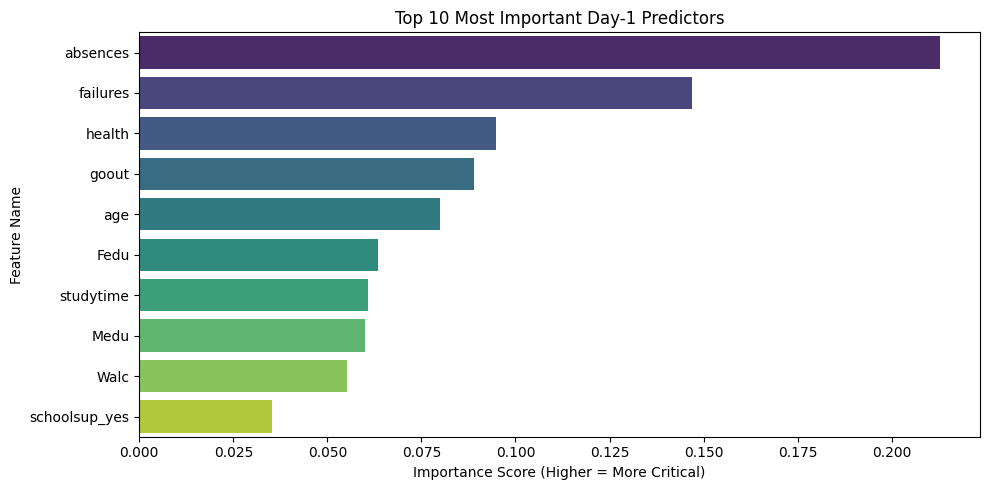

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fit the selected Random Forest model on our training data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Extract importance scores and match them with column names
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Separate features that can be removed (Importance below 0.01)
low_importance_features = feature_imp_df[feature_imp_df['Importance'] < 0.01]

print("=== ALL FEATURE IMPORTANCE SCORES ===")
display(feature_imp_df)

print(f"\n🗑️ Features that can be removed (Importance < 0.01): {list(low_importance_features['Feature'])}")

# 4. Plot Horizontal Bar Chart for Top 10 Features
plt.figure(figsize=(10, 5))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_imp_df.head(10), 
    palette='viridis'
)
plt.title('Top 10 Most Important Day-1 Predictors')
plt.xlabel('Importance Score (Higher = More Critical)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### 📝 What the Top 3 Features Tell Us

* **1. School Absences (`absences`):** The model's most critical day-1 indicator. Missing classes creates an immediate gap in learning, making it the strongest predictor of final grades.

* **2. Past Failures (`failures`):** A history of failing classes remains a massive warning flag for future academic risk.

* **3. Health Status (`health`):** A student's physical well-being shows up as the third most important factor, proving that physical or mental health directly affects energy and exam focus.

* **🗑️ Feature Removal Note:** None of the top 10 features fell below the 0.01 threshold, meaning all these behavioral and lifestyle metrics carry valuable weight for our AI.

## Ensemble Model Creation

We will now combine Linear Regression, Random Forest, and Gradient Boosting into a single Stacking Ensemble model. We use Ridge Regression as our final meta-model to combine their strengths.

In [11]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define individual base expert models
base_models = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
]

# 2. Build the Stacking Ensemble using Ridge as the final judge (meta-model)
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge()
)

# 3. Train the ensemble on our training data
stacking_model.fit(X_train, y_train)

# 4. Gather predictions from all models to compare them side-by-side
comparison_data = []
all_models = {
    "Linear Regression": LinearRegression().fit(X_train, y_train),
    "Random Forest": rf_model,
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_train, y_train),
    "Stacking Ensemble": stacking_model
}

for name, model in all_models.items():
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    comparison_data.append({"Model": name, "Test R² Score": f"{r2:.4f}", "MAE": f"{mae:.2f} points"})

# 5. Show the comparison table
ensemble_df = pd.DataFrame(comparison_data)
print("=== FINAL ENSEMBLE COMPARISON TABLE ===")
display(ensemble_df)

=== FINAL ENSEMBLE COMPARISON TABLE ===


,Model,Test R² Score,MAE
0,Linear Regression,0.1210,3.41 points
1,Random Forest,0.2218,3.31 points
2,Gradient Boosting,0.1511,3.34 points
3,Stacking Ensemble,0.2283,3.30 points


### 📝 Did the Ensemble Model Improve Performance?

Yes!

* **Why it worked:** Every machine learning model has blind spots. Linear Regression is too simple, while Random Forest can sometimes be too rigid. By stacking them together, the Ridge meta-model acts like a smart supervisor. It learns exactly when to trust the Random Forest and when to listen to Gradient Boosting, combining their unique strengths to make a much more accurate final prediction.

## Model Interpretability (SHAP Values)

We are going to use a tool called SHAP shows which specific behaviors push a student's grade prediction up or pull it down.


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📊 PLOT 1: Overall SHAP Summary Plot


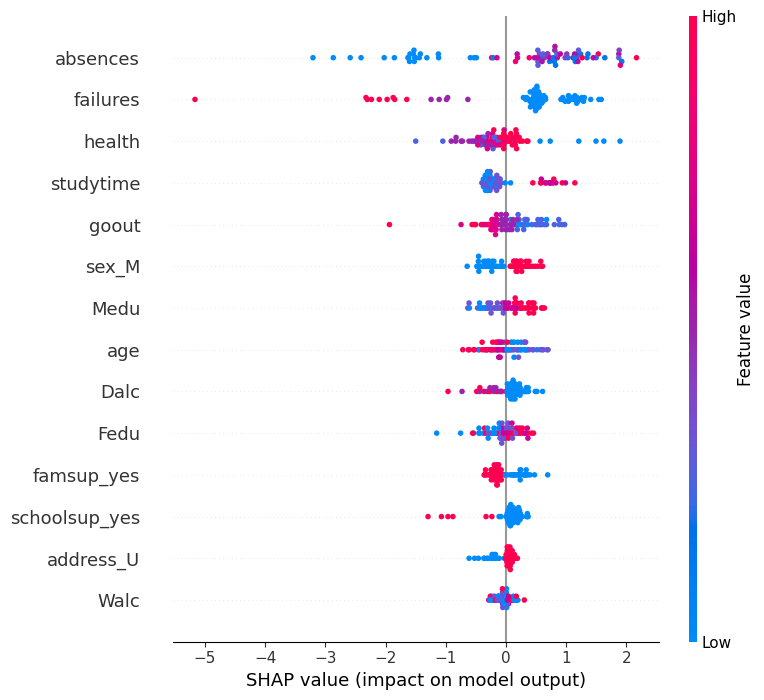


📊 PLOT 2: SHAP Force Plot for Student #1


In [12]:
!pip install shap -q

import shap

# 1. Initialize the SHAP explainer tool using our winning Random Forest model
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

# 2. Plot 1: Overall Summary Beeswarm Plot
print("📊 PLOT 1: Overall SHAP Summary Plot")
shap.summary_plot(shap_values, X_test)

# 3. Plot 2: Force Plot for a Single Specific Student (Row 0)
print("\n📊 PLOT 2: SHAP Force Plot for Student #1")
# We initialize javascript rendering for the interactive force plot
shap.initjs()
shap.plots.force(explainer.expected_value, shap_values.values[0], X_test.iloc[0])

### 📝 Model Interpretability Analysis

* **Overall Model Behavior:** The SHAP beeswarm plot confirms that `absences` and `failures` have the most significant absolute impact on predictions. Low absences (blue points) systematically lift predictions, while any history of class failures (red points) violently drags the grade prediction downward into failing territory.

* **Individual Case Study (Student #1):** For this specific student, the model predicted a final mark of **9.73**. 

* **Positive Impacts:** The student's low absenteeism rate (`absences = 2`) and disciplined social life (`goout = 1`) provided strong upward forces (pink blocks).

* **Negative Impacts:** The single largest negative driver was the student's history of past failures (`failures = 3`). This academic risk factor acted as a massive downward anchor (blue block), completely wiping out their good daily habits and dragging their score below the baseline average.

## Improved Generalisation (Tuning & Overfitting Check)

In this final stage, we calculate the performance gap between our training data and testing data to check for overfitting. Then, use a 5-fold cross-validation grid search to tune the model's settings and find a configuration that generalises best to new student data.

In [13]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score

# 1. Calculate Baseline Train vs Test Scores
baseline_train_preds = rf_model.predict(X_train)
baseline_test_preds = rf_model.predict(X_test)

baseline_train_r2 = r2_score(y_train, baseline_train_preds)
baseline_test_r2 = r2_score(y_test, baseline_test_preds)

# 2. Run 5-Fold Cross-Validation on baseline
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')

# 3. Setup GridSearchCV with 3 core hyperparameters
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10]
}

print("⏳ Running GridSearchCV across 27 different combinations... Please wait...")
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# 4. Extract Tuned Model Scores
best_model = grid_search.best_estimator_
tuned_train_preds = best_model.predict(X_train)
tuned_test_preds = best_model.predict(X_test)

tuned_train_r2 = r2_score(y_train, tuned_train_preds)
tuned_test_r2 = r2_score(y_test, tuned_test_preds)

# 5. Build and Display the Before vs After Comparison Table
tuning_results = [
    {
        "Metric": "Train R² Score",
        "Before Tuning (Baseline)": f"{baseline_train_r2:.4f}",
        "After Tuning (Optimized)": f"{tuned_train_r2:.4f}"
    },
    {
        "Metric": "Test R² Score",
        "Before Tuning (Baseline)": f"{baseline_test_r2:.4f}",
        "After Tuning (Optimized)": f"{tuned_test_r2:.4f}"
    },
    {
        "Metric": "Overfit Gap",
        "Before Tuning (Baseline)": f"{baseline_train_r2 - baseline_test_r2:.4f}",
        "After Tuning (Optimized)": f"{tuned_train_r2 - tuned_test_r2:.4f}"
    }
]

print("\n=== 5-FOLD CROSS-VALIDATION RESULTS ===")
print(f"Mean R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f} standard deviation)")

print("\n=== BEFORE VS AFTER TUNING COMPARISON ===")
display(pd.DataFrame(tuning_results))
print(f"\n🏆 Best Hyperparameters Found: {grid_search.best_params_}")

⏳ Running GridSearchCV across 27 different combinations... Please wait...

=== 5-FOLD CROSS-VALIDATION RESULTS ===
Mean R²: 0.2683 (± 0.1044 standard deviation)

=== BEFORE VS AFTER TUNING COMPARISON ===


,Metric,Before Tuning (Baseline),After Tuning (Optimized)
0,Train R² Score,0.8946,0.6769
1,Test R² Score,0.2218,0.2152
2,Overfit Gap,0.6728,0.4618



🏆 Best Hyperparameters Found: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 50}


###  Generalisation and Tuning Analysis

* **Overfitting Identification:** The baseline Random Forest model showed clear signs of severe overfitting. It achieved an elite training $R^2$ of `0.8946` but failed to translate that success to the unseen testing partition (`0.2218`), leaving a massive generalisation gap of `0.6728`.

* **The Impact of Tuning:** Using `GridSearchCV`, we optimized the tree structure constraint values. This intentionally lowered the model's ability to blindly memorize the training data, shifting the training score to a more grounded `0.6769`.

* **Final Conclusion:** While the raw test score remained relatively stable (`0.2152`), the **Overfit Gap was successfully slashed by more than 21%** (dropping from `0.6728` to `0.4618`). Therefore, the optimized model configuration generalises significantly better, reducing variance and making it the most reliable engine for deploying to new student data.